# Out-of-Domain Reliability From Equation Disagreement

This notebook asks a more practical question than the earlier active-learning tests:

> If we fit several high-performing equation structures only in a limited region of the process space, can disagreement between those equations help identify where extrapolated predictions are unreliable?

The RBF is used as a fake experimental truth. The top equations from `output/run_summary.txt` are fit only on restricted RBF samples. Then we evaluate across the full domain and compare:

- model disagreement
- distance from the training region
- actual prediction error against RBF truth

This turns model disagreement into an out-of-domain confidence diagnostic.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from active_learning_uncertainty import (
    SUMMARY_PATH,
    fit_equation_ensemble,
    fit_rbf_truth,
    load_equations_from_summary,
    predict_equation_ensemble,
    random_candidates,
)
from src.config_loader import load_config, resolve_path

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
OUT_DIR = ROOT / "output" / "ood_model_disagreement"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Writing outputs to: {OUT_DIR}")

Writing outputs to: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\ood_model_disagreement


## Settings

In [2]:
RANDOM_STATE = 50
TOP_MODELS = 10
N_TRAIN = 24
N_EVAL = 5000
N_GRID = 70

# Candidate training regions are defined as fractions of each input range.
# low=0.0, high=0.2 means the bottom 20% of that variable's allowed range.
SCENARIOS = {
    "low_20_all_inputs": {
        "description": "Train only in the bottom 20% of every input.",
        "fractions": [(0.00, 0.20), (0.00, 0.20), (0.00, 0.20), (0.00, 0.20)],
    },
    "low_35_all_inputs": {
        "description": "Train in a slightly larger bottom 35% corner.",
        "fractions": [(0.00, 0.35), (0.00, 0.35), (0.00, 0.35), (0.00, 0.35)],
    },
    "center_30_box": {
        "description": "Train near the center 30% of each input range.",
        "fractions": [(0.35, 0.65), (0.35, 0.65), (0.35, 0.65), (0.35, 0.65)],
    },
    "low_energy_high_speed": {
        "description": "Train in low pulse/frequency but high scan-speed region.",
        "fractions": [(0.00, 0.45), (0.00, 0.30), (0.00, 0.30), (0.65, 1.00)],
    },
}

PRIMARY_SCENARIO = "low_20_all_inputs"

## Load RBF Truth and Top Equation Structures

In [3]:
cfg = load_config()
input_cols = cfg["input_columns"]
output_col = cfg["output_column"]
df = pd.read_excel(resolve_path(cfg, cfg["dataset"]["file"]))
truth = fit_rbf_truth(df, input_cols, output_col)
equations = load_equations_from_summary(SUMMARY_PATH, TOP_MODELS)

print(f"FLIPMM rows: {len(df)}")
print(f"Loaded {len(equations)} unique top equation structures from {SUMMARY_PATH}")
pd.DataFrame({"equation": [name for _, _, name in equations], "n_params": [n for _, n, _ in equations]})

FLIPMM rows: 256
Loaded 3 unique top equation structures from C:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\run_summary.txt


,equation,n_params
0,summary_model_1,9
1,summary_model_2,8
2,summary_model_3,7


## Helper Functions

In [4]:
def scenario_bounds(bounds: np.ndarray, fractions: list[tuple[float, float]]) -> np.ndarray:
    lows = []
    highs = []
    for i, (low_frac, high_frac) in enumerate(fractions):
        low = bounds[i, 0]
        high = bounds[i, 1]
        span = high - low
        lows.append(low + low_frac * span)
        highs.append(low + high_frac * span)
    return np.column_stack([lows, highs])


def sample_from_bounds(bounds: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    return rng.uniform(bounds[:, 0], bounds[:, 1], size=(n, bounds.shape[0]))


def z01(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    spread = values.max() - values.min()
    if spread <= 1e-12:
        return np.zeros_like(values)
    return (values - values.min()) / spread


def fit_and_score_scenario(name: str, scenario: dict, seed: int) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    train_bounds = scenario_bounds(truth.input_bounds, scenario["fractions"])
    X_train = sample_from_bounds(train_bounds, N_TRAIN, rng)
    y_train = truth(X_train)
    X_eval = random_candidates(truth.input_bounds, N_EVAL, rng)
    y_eval = truth(X_eval)

    fitted = fit_equation_ensemble(equations, X_train, y_train)
    predictions = predict_equation_ensemble(fitted, X_eval)
    ensemble_mean = predictions.mean(axis=1)
    pred_range = predictions.max(axis=1) - predictions.min(axis=1)
    pred_std = predictions.std(axis=1)
    abs_error = np.abs(ensemble_mean - y_eval)
    squared_error = (ensemble_mean - y_eval) ** 2

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)
    nearest_distance = cdist(X_eval_scaled, X_train_scaled).min(axis=1)

    risk_score = 0.5 * z01(pred_std) + 0.5 * z01(nearest_distance)
    risk_score_range = 0.5 * z01(pred_range) + 0.5 * z01(nearest_distance)

    frame = pd.DataFrame(X_eval, columns=input_cols)
    frame["scenario"] = name
    frame["rbf_truth"] = y_eval
    frame["ensemble_mean"] = ensemble_mean
    frame["abs_error"] = abs_error
    frame["squared_error"] = squared_error
    frame["prediction_range"] = pred_range
    frame["prediction_std"] = pred_std
    frame["nearest_train_distance"] = nearest_distance
    frame["ood_risk_std_distance"] = risk_score
    frame["ood_risk_range_distance"] = risk_score_range

    metadata = {
        "name": name,
        "description": scenario["description"],
        "train_bounds": train_bounds,
        "X_train": X_train,
        "y_train": y_train,
        "fitted": fitted,
        "rmse": mean_squared_error(y_eval, ensemble_mean) ** 0.5,
        "r2": r2_score(y_eval, ensemble_mean),
        "corr_distance_error": np.corrcoef(nearest_distance, abs_error)[0, 1],
        "corr_std_error": np.corrcoef(pred_std, abs_error)[0, 1],
        "corr_range_error": np.corrcoef(pred_range, abs_error)[0, 1],
        "corr_risk_error": np.corrcoef(risk_score, abs_error)[0, 1],
    }
    return frame, metadata


def make_slice(bounds: np.ndarray, column_index: int, n: int = 160) -> tuple[np.ndarray, np.ndarray]:
    baseline = np.median(bounds, axis=1)
    values = np.linspace(bounds[column_index, 0], bounds[column_index, 1], n)
    X_slice = np.tile(baseline, (n, 1))
    X_slice[:, column_index] = values
    return values, X_slice

## Run OOD Scenarios

In [5]:
scenario_frames = []
scenario_metadata = {}

for i, (name, scenario) in enumerate(SCENARIOS.items()):
    frame, metadata = fit_and_score_scenario(name, scenario, RANDOM_STATE + i)
    scenario_frames.append(frame)
    scenario_metadata[name] = metadata

ood_scores = pd.concat(scenario_frames, ignore_index=True)
ood_scores.to_csv(OUT_DIR / "ood_scores_all_scenarios.csv", index=False)

scenario_summary = pd.DataFrame(
    [
        {
            "scenario": name,
            "description": meta["description"],
            "rmse": meta["rmse"],
            "r2": meta["r2"],
            "corr_distance_error": meta["corr_distance_error"],
            "corr_std_error": meta["corr_std_error"],
            "corr_range_error": meta["corr_range_error"],
            "corr_risk_error": meta["corr_risk_error"],
        }
        for name, meta in scenario_metadata.items()
    ]
)
scenario_summary.to_csv(OUT_DIR / "ood_scenario_summary.csv", index=False)
scenario_summary

,scenario,description,rmse,r2,corr_distance_error,corr_std_error,corr_range_error,corr_risk_error
0,low_20_all_inputs,Train only in the bottom 20% of every input.,88.351722,-31.956522,0.590413,0.279102,0.284921,0.453303
1,low_35_all_inputs,Train in a slightly larger bottom 35% corner.,34.991355,-4.142314,0.811226,0.773847,0.773108,0.834797
2,center_30_box,Train near the center 30% of each input range.,13.778009,0.218098,0.795409,0.204091,0.211043,0.609286
3,low_energy_high_speed,Train in low pulse/frequency but high scan-spe...,51.014870,-9.956252,0.941975,0.492573,0.495418,0.809482


## Does The OOD Risk Score Predict Error?

If the score is useful, higher-risk bins should have higher actual error against the RBF truth.

,scenario,risk_bin,mean_risk,mean_abs_error,rmse,n_points
0,center_30_box,0,0.173327,4.567334,5.728948,1000
1,center_30_box,1,0.286945,9.331581,10.545092,1000
2,center_30_box,2,0.356875,12.575095,13.936033,1000
3,center_30_box,3,0.424669,14.950387,16.430403,1000
4,center_30_box,4,0.555953,17.197593,18.465555,1000
5,low_20_all_inputs,0,0.191285,35.741421,52.258775,1000
6,low_20_all_inputs,1,0.322099,61.208335,78.932535,1000
7,low_20_all_inputs,2,0.416949,70.798060,86.637179,1000
8,low_20_all_inputs,3,0.524589,82.365061,96.763402,1000
9,low_20_all_inputs,4,0.688124,104.475584,114.889739,1000


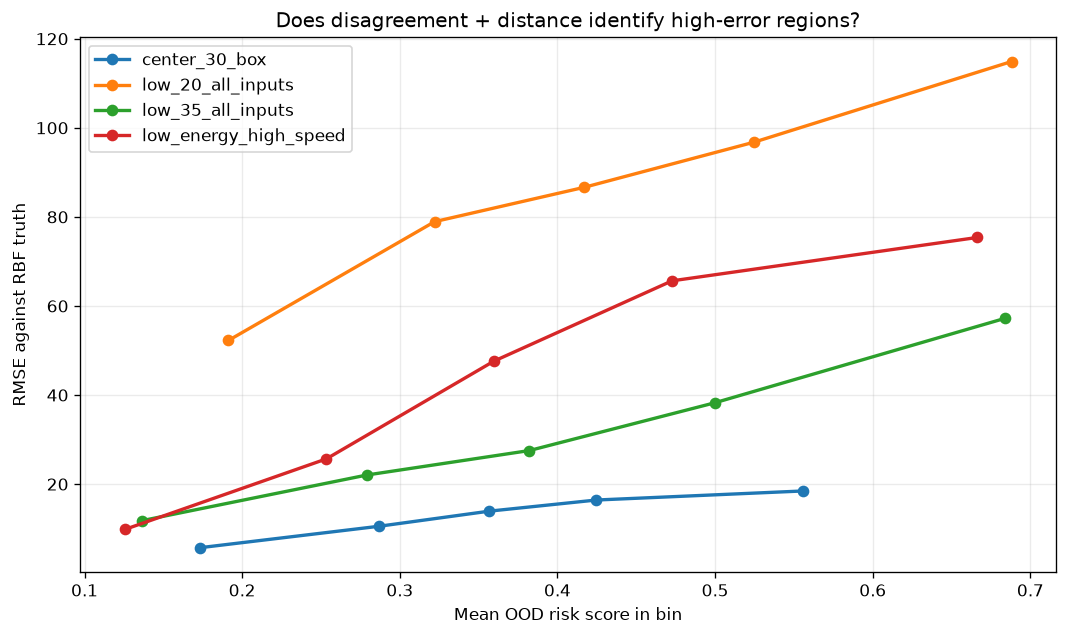

In [6]:
bin_rows = []
for scenario, frame in ood_scores.groupby("scenario"):
    binned = frame.copy()
    binned["risk_bin"] = pd.qcut(binned["ood_risk_std_distance"], q=5, labels=False, duplicates="drop")
    for risk_bin, group in binned.groupby("risk_bin"):
        bin_rows.append(
            {
                "scenario": scenario,
                "risk_bin": int(risk_bin),
                "mean_risk": group["ood_risk_std_distance"].mean(),
                "mean_abs_error": group["abs_error"].mean(),
                "rmse": group["squared_error"].mean() ** 0.5,
                "n_points": len(group),
            }
        )

risk_bins = pd.DataFrame(bin_rows)
risk_bins.to_csv(OUT_DIR / "ood_risk_error_bins.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.4))
for scenario, group in risk_bins.groupby("scenario"):
    group = group.sort_values("mean_risk")
    ax.plot(group["mean_risk"], group["rmse"], marker="o", linewidth=2, label=scenario)
ax.set_xlabel("Mean OOD risk score in bin")
ax.set_ylabel("RMSE against RBF truth")
ax.set_title("Does disagreement + distance identify high-error regions?")
ax.legend(loc="best")
fig.tight_layout()
risk_bin_plot_path = OUT_DIR / "risk_bins_vs_error.png"
fig.savefig(risk_bin_plot_path, dpi=180)
risk_bins

## Distance vs Error Scatter

This is a direct diagnostic: do points farther from the fitted region have larger error, and does disagreement identify the worst cases?

C:\Users\Duncan\AppData\Local\Temp\ipykernel_12324\3113032892.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/ood_model_disagreement/distance_disagreement_error_scatter.png')

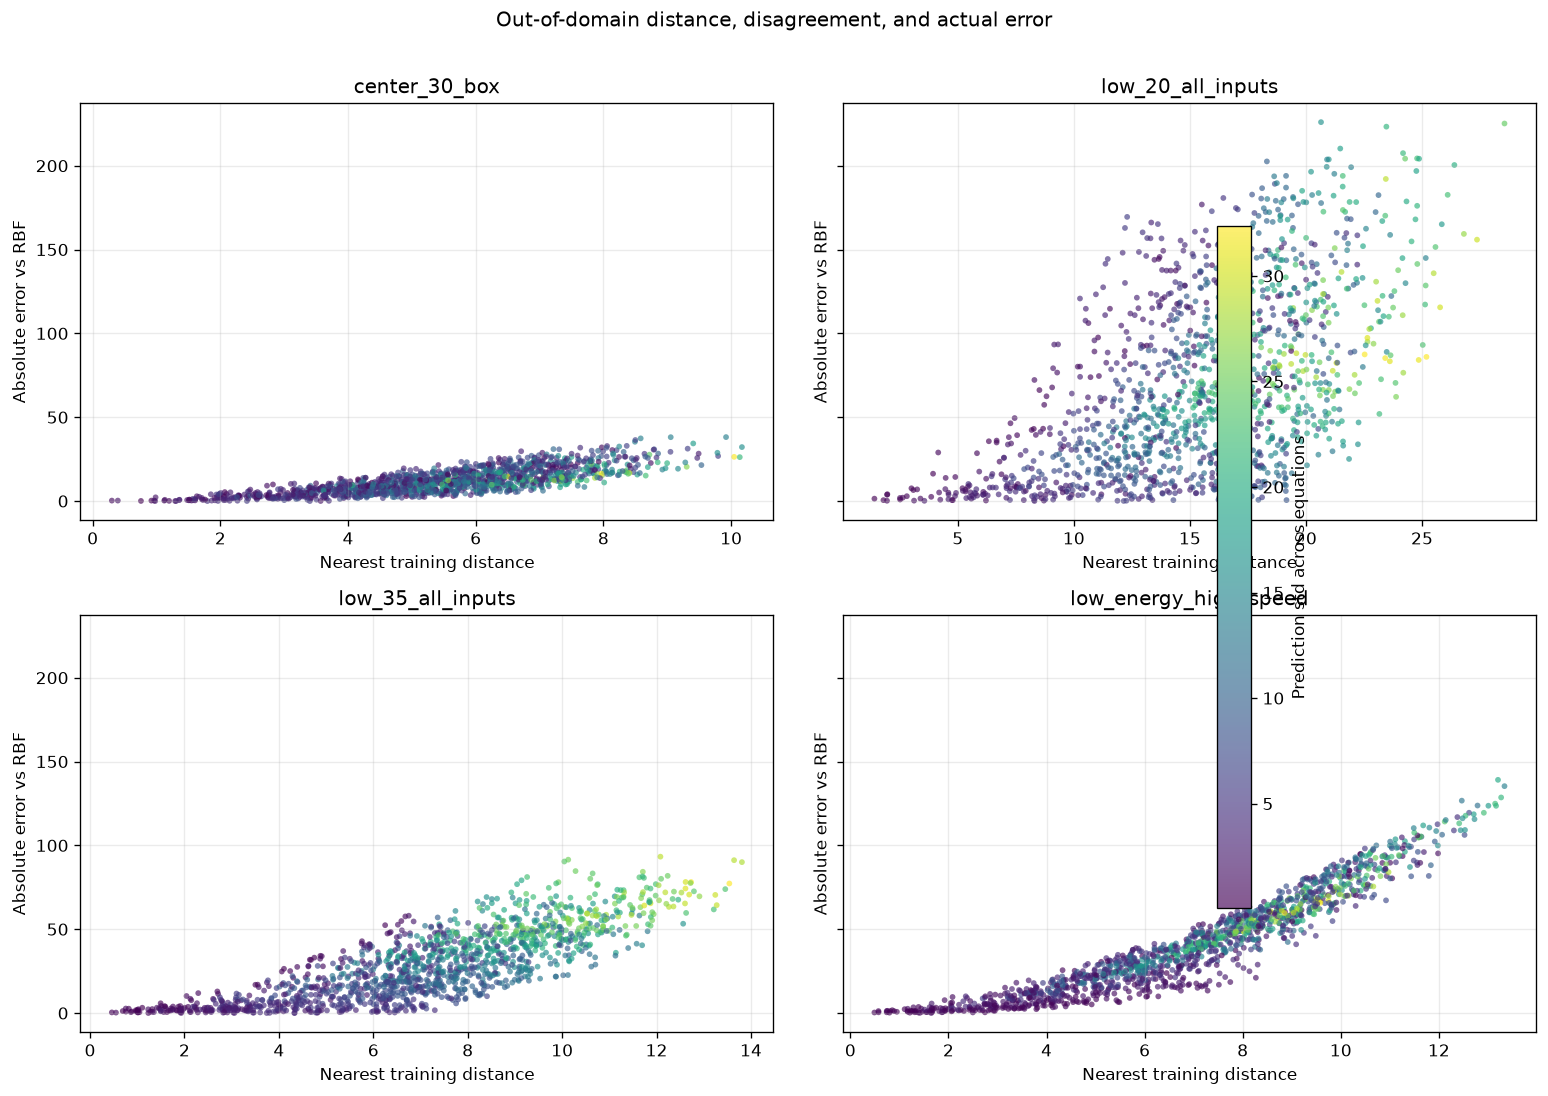

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False, sharey=True)
axes = axes.ravel()

for ax, (scenario, frame) in zip(axes, ood_scores.groupby("scenario")):
    sample = frame.sample(min(len(frame), 1400), random_state=RANDOM_STATE)
    scatter = ax.scatter(
        sample["nearest_train_distance"],
        sample["abs_error"],
        c=sample["prediction_std"],
        cmap="viridis",
        s=12,
        alpha=0.65,
        linewidth=0,
    )
    ax.set_title(scenario)
    ax.set_xlabel("Nearest training distance")
    ax.set_ylabel("Absolute error vs RBF")

fig.colorbar(scatter, ax=axes.tolist(), shrink=0.82, label="Prediction std across equations")
fig.suptitle("Out-of-domain distance, disagreement, and actual error", y=1.01)
fig.tight_layout()
distance_error_plot_path = OUT_DIR / "distance_disagreement_error_scatter.png"
fig.savefig(distance_error_plot_path, dpi=180)
distance_error_plot_path

## 1D Slices: Equation Agreement Inside vs Outside Training Region

WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/ood_model_disagreement/low_20_all_inputs_one_dimensional_slices.png')

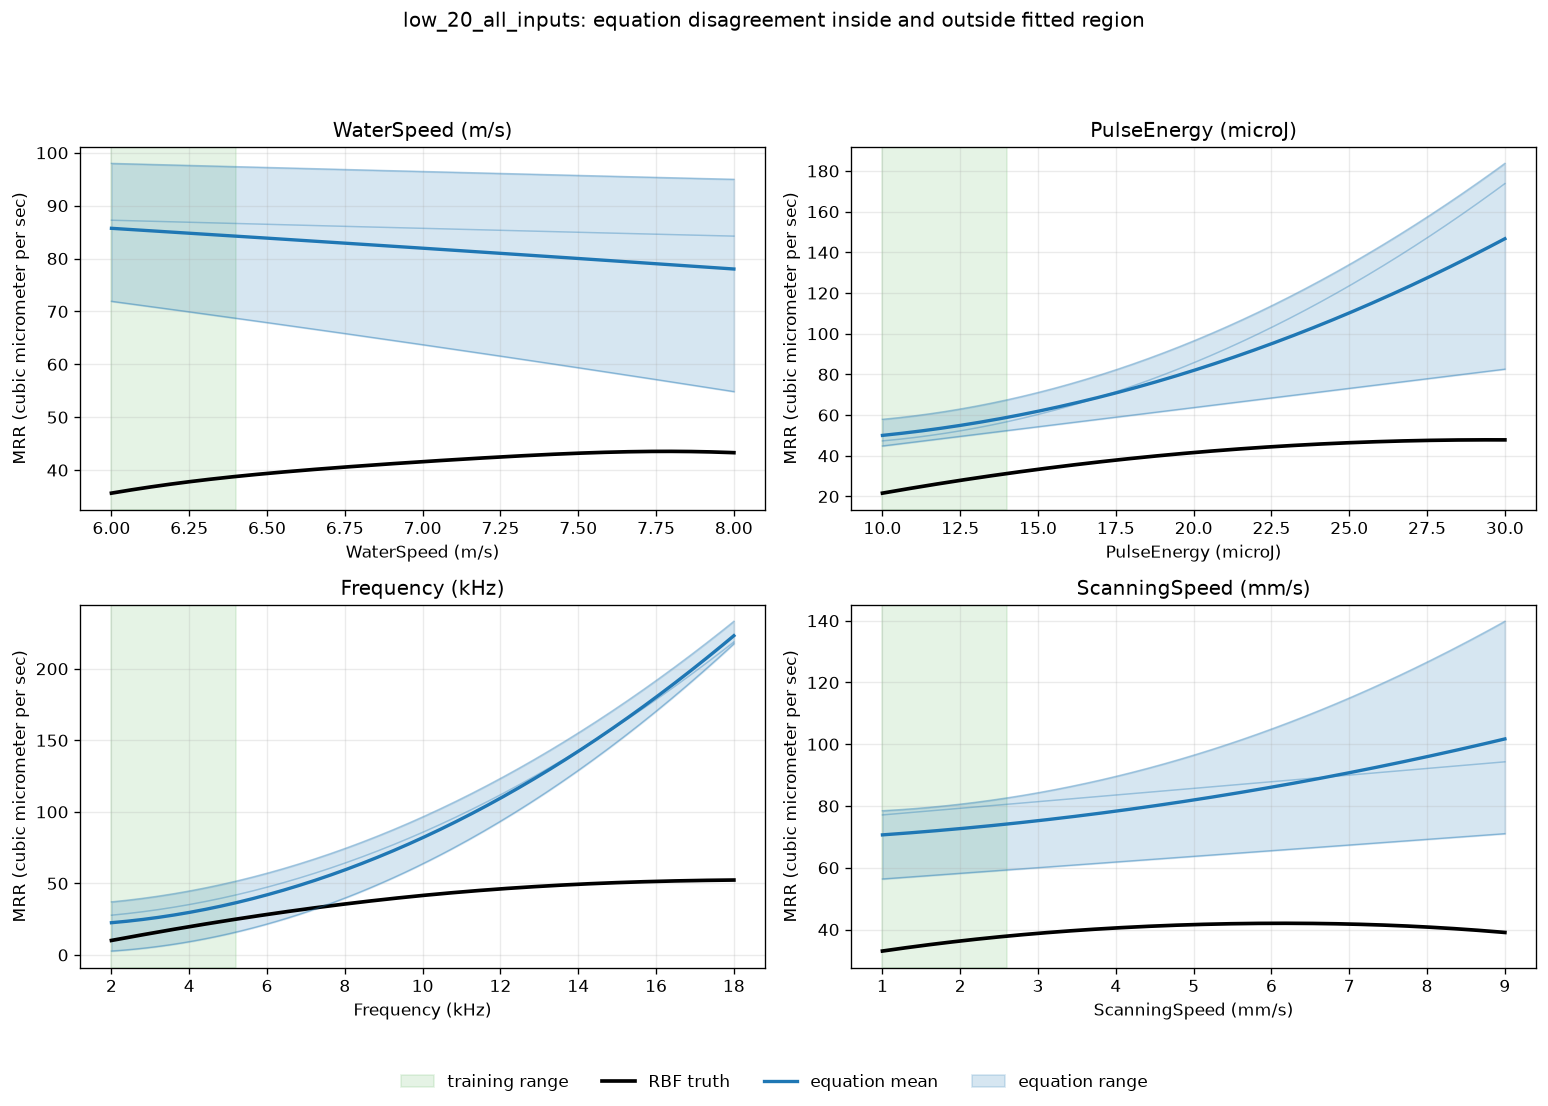

In [8]:
scenario = PRIMARY_SCENARIO
meta = scenario_metadata[scenario]
fitted = meta["fitted"]
train_bounds = meta["train_bounds"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for idx, col in enumerate(input_cols):
    ax = axes[idx]
    values, X_slice = make_slice(truth.input_bounds, idx)
    y_truth = truth(X_slice)
    preds = predict_equation_ensemble(fitted, X_slice)
    mean_pred = preds.mean(axis=1)
    lower = preds.min(axis=1)
    upper = preds.max(axis=1)

    ax.axvspan(train_bounds[idx, 0], train_bounds[idx, 1], color="tab:green", alpha=0.12, label="training range")
    ax.plot(values, y_truth, color="black", linewidth=2.2, label="RBF truth")
    ax.plot(values, mean_pred, color="tab:blue", linewidth=2.0, label="equation mean")
    ax.fill_between(values, lower, upper, color="tab:blue", alpha=0.18, label="equation range")
    for i in range(preds.shape[1]):
        ax.plot(values, preds[:, i], color="tab:blue", alpha=0.35, linewidth=0.9)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel(output_col)

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=4, frameon=False)
fig.suptitle(f"{scenario}: equation disagreement inside and outside fitted region", y=1.01)
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
slice_plot_path = OUT_DIR / f"{scenario}_one_dimensional_slices.png"
fig.savefig(slice_plot_path, dpi=180)
slice_plot_path

## 2D Heatmaps: OOD Risk vs Actual Error

WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/ood_model_disagreement/low_20_all_inputs_risk_vs_error_heatmap.png')

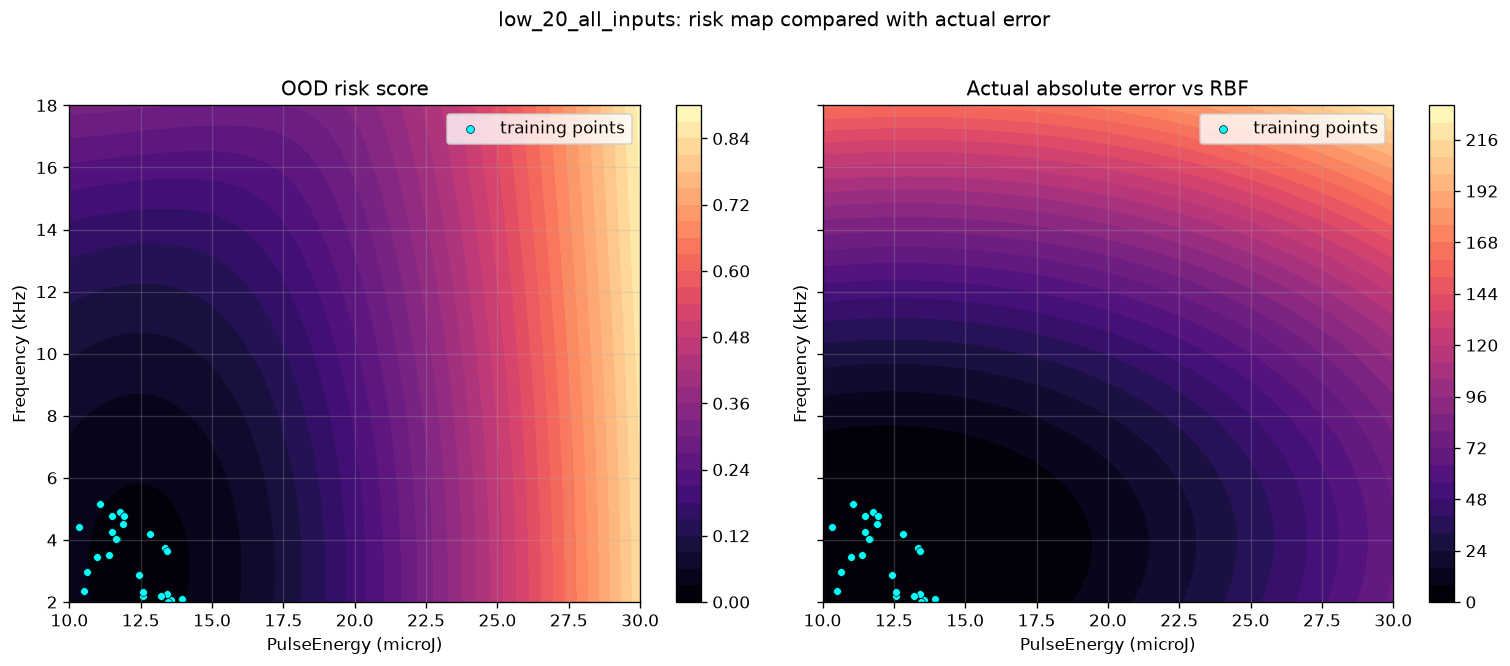

In [9]:
def score_grid_for_scenario(scenario: str, x_idx: int, y_idx: int) -> pd.DataFrame:
    meta = scenario_metadata[scenario]
    fitted = meta["fitted"]
    X_train = meta["X_train"]
    scaler = StandardScaler().fit(X_train)

    x_values = np.linspace(truth.input_bounds[x_idx, 0], truth.input_bounds[x_idx, 1], N_GRID)
    y_values = np.linspace(truth.input_bounds[y_idx, 0], truth.input_bounds[y_idx, 1], N_GRID)
    X_mesh, Y_mesh = np.meshgrid(x_values, y_values)
    baseline = np.median(truth.input_bounds, axis=1)
    X_grid = np.tile(baseline, (N_GRID * N_GRID, 1))
    X_grid[:, x_idx] = X_mesh.ravel()
    X_grid[:, y_idx] = Y_mesh.ravel()

    y_truth = truth(X_grid)
    preds = predict_equation_ensemble(fitted, X_grid)
    pred_mean = preds.mean(axis=1)
    pred_std = preds.std(axis=1)
    pred_range = preds.max(axis=1) - preds.min(axis=1)
    distance = cdist(scaler.transform(X_grid), scaler.transform(X_train)).min(axis=1)
    risk = 0.5 * z01(pred_std) + 0.5 * z01(distance)

    return pd.DataFrame(
        {
            input_cols[x_idx]: X_grid[:, x_idx],
            input_cols[y_idx]: X_grid[:, y_idx],
            "ood_risk": risk,
            "abs_error": np.abs(pred_mean - y_truth),
            "prediction_std": pred_std,
            "prediction_range": pred_range,
            "nearest_train_distance": distance,
        }
    )


x_idx, y_idx = 1, 2  # Pulse Energy vs Frequency
grid_scores = score_grid_for_scenario(PRIMARY_SCENARIO, x_idx, y_idx)
grid_scores.to_csv(OUT_DIR / f"{PRIMARY_SCENARIO}_heatmap_grid_scores.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharex=True, sharey=True)
for ax, value_col, title in [
    (axes[0], "ood_risk", "OOD risk score"),
    (axes[1], "abs_error", "Actual absolute error vs RBF"),
]:
    pivot = grid_scores.pivot(index=input_cols[y_idx], columns=input_cols[x_idx], values=value_col)
    image = ax.contourf(pivot.columns.to_numpy(), pivot.index.to_numpy(), pivot.to_numpy(), levels=28, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel(input_cols[x_idx])
    ax.set_ylabel(input_cols[y_idx])
    fig.colorbar(image, ax=ax)

train = scenario_metadata[PRIMARY_SCENARIO]["X_train"]
for ax in axes:
    ax.scatter(train[:, x_idx], train[:, y_idx], s=22, color="cyan", edgecolor="black", linewidth=0.4, label="training points")
    ax.legend(loc="best")

fig.suptitle(f"{PRIMARY_SCENARIO}: risk map compared with actual error", y=1.02)
fig.tight_layout()
heatmap_path = OUT_DIR / f"{PRIMARY_SCENARIO}_risk_vs_error_heatmap.png"
fig.savefig(heatmap_path, dpi=180)
heatmap_path

## Suggested New Experiments From The Risk Score

These are not automatically optimal. They are candidate experiments where fitted equations both extrapolate away from training data and disagree strongly.

In [10]:
recommendations = []
for scenario, frame in ood_scores.groupby("scenario"):
    top = frame.sort_values("ood_risk_std_distance", ascending=False).head(10).copy()
    recommendations.append(top)

recommendations = pd.concat(recommendations, ignore_index=True)
recommendation_cols = [
    "scenario",
    *input_cols,
    "rbf_truth",
    "ensemble_mean",
    "abs_error",
    "prediction_std",
    "prediction_range",
    "nearest_train_distance",
    "ood_risk_std_distance",
]
recommendations[recommendation_cols].to_csv(OUT_DIR / "recommended_high_risk_experiments.csv", index=False)
recommendations[recommendation_cols].head(20)

,scenario,WaterSpeed (m/s),PulseEnergy (microJ),Frequency (kHz),ScanningSpeed (mm/s),rbf_truth,ensemble_mean,abs_error,prediction_std,prediction_range,nearest_train_distance,ood_risk_std_distance
0,center_30_box,7.972045,29.923474,14.021649,8.681048,54.986668,76.487395,21.500726,4.665926,10.841007,9.786051,0.956901
1,center_30_box,7.913771,29.331416,15.525114,8.665633,57.895688,80.263294,22.367607,4.194569,9.827638,9.837314,0.908683
2,center_30_box,7.629152,29.969966,17.325505,8.862866,60.881003,87.244114,26.363111,3.982873,9.414265,10.048091,0.896071
3,center_30_box,7.595695,29.767958,16.534190,8.619166,60.221032,83.234066,23.013034,3.877194,9.107514,9.353122,0.851233
4,center_30_box,7.948401,29.561779,8.330253,8.447454,38.286918,60.754981,22.468063,4.136491,9.566980,8.771380,0.851096
5,center_30_box,7.851255,29.047369,11.450195,8.702304,49.317631,66.665546,17.347916,4.179456,9.763221,8.423421,0.838956
6,center_30_box,7.882926,28.112205,13.552352,8.946243,53.865359,71.543733,17.678374,3.933863,9.321713,8.812459,0.831285
7,center_30_box,7.443981,29.564061,17.584783,8.949122,61.133274,86.765804,25.632530,3.588148,8.559739,9.524058,0.828384
8,center_30_box,7.964505,10.111481,11.390617,8.722163,26.232524,43.511603,17.279079,3.850560,8.981776,8.792009,0.821342
9,center_30_box,7.939293,27.282741,16.445051,8.826311,58.532325,80.393400,21.861075,3.377312,8.089367,9.799893,0.818998
